# Seed Disambiguation Diagnostic

Checks whether each seed in `ANCHOR_SEEDS` + `CENTROID_EXTRAS` unambiguously points  
to its assigned bin, or whether it sits closer to a rival bin in W2V space.

**Method (Alternative 1 — Disambiguation Score):**  
For each seed, rebuild all three centroids *without* that seed, then compute:

```
margin = sim(seed, own_centroid) - max(sim(seed, rival_centroids))
```

- **margin > 0.05** → seed pulls clearly toward its own bin ✓  
- **margin near 0** → seed is equidistant between bins — ambiguous  
- **margin < 0** → seed is closer to a rival bin — likely a contaminant

## 1 — Imports & Config

In [1]:
import pandas as pd
import numpy as np
import re

from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from IPython.display import display, HTML

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# ── W2V config — must match v2 exactly so the embedding space is comparable ───
W2V_DIM       = 100
W2V_WINDOW    = 6
W2V_EPOCHS    = 30
W2V_SG        = 1
W2V_MIN_COUNT = 3

BIN_NAMES = ['physical', 'technique', 'character']

print('Imports OK')

Imports OK


## 2 — Preprocessing (identical to v2)

In [2]:
_CURATED_RAW = {
    'change of direction': 'change_of_direction', 'low pad level': 'low_pad_level',
    'run after catch': 'run_after_catch', 'yards after contact': 'yards_after_contact',
    'yards after catch': 'yards_after_catch', 'run after contact': 'run_after_contact',
    'off the line': 'off_the_line', 'off the ball': 'off_the_ball',
    'point of attack': 'point_of_attack', 'get off the line': 'get_off_the_line',
    'read and react': 'read_and_react', 'inside the box': 'inside_the_box',
    'stack and shed': 'stack_and_shed', 'pass rush moves': 'pass_rush_moves',
    'tackles for loss': 'tackles_for_loss', 'tackle for loss': 'tackle_for_loss',
    'setting the edge': 'setting_edge', 'set the edge': 'setting_edge',
    'turn the corner': 'turn_the_corner', 'flatten the arc': 'flatten_arc',
    'low to the ground': 'low_to_ground', 'beat the punch': 'beat_the_punch',
    'block take on': 'block_takeon', 'block take-on': 'block_takeon',
    'make plays': 'play_making', 'makes plays': 'play_making',
    'generates pressure': 'generate_pressure', 'generate pressure': 'generate_pressure',
    'creates pressure': 'generate_pressure', 'north south': 'north_south',
    'north-south': 'north_south', 'balanced base': 'balanced_base',
    'wide base': 'wide_base', 'burst of speed': 'burst_of_speed',
    'arm strength': 'arm_strength', 'leg drive': 'leg_drive',
    'catch radius': 'catch_radius', 'catching radius': 'catch_radius',
    'hip tightness': 'hip_tightness', 'tight hips': 'hip_tightness',
    'hip bend': 'hip_bend', 'bend the edge': 'bend_edge',
    'lean frame': 'lean_frame', 'thick frame': 'thick_frame',
    'raw speed': 'raw_speed', 'raw power': 'raw_power',
    'straight line speed': 'straight_line_speed', 'straight-line speed': 'straight_line_speed',
    'grip strength': 'grip_strength', 'wrist flick': 'wrist_flick',
    'change-of-direction': 'change_of_direction', 'release point': 'release_point',
    'arm angles': 'arm_angles', 'arm angle': 'arm_angles',
    'sees pressure': 'blitz_awareness', 'reads pressure': 'blitz_awareness',
    'tight window': 'tight_windows', 'tight windows': 'tight_windows',
    'drive throws': 'drive_throw', 'cannon arm': 'cannon',
    'body control': 'body_control', 'quick release': 'quick_delivery',
    'pocket passer': 'pocket_passer', 'lower half': 'lower_half',
    'lower body': 'lower_body', 'upper body': 'upper_body',
    'explosive hips': 'explosive_hips', 'spin move': 'spin_move',
    'swim move': 'swim_move', 'speed rush': 'speed_rush',
    'counter move': 'counter_move', 'rush move': 'rush_moves',
    'rush moves': 'rush_moves', 'bull rush': 'bull_rush',
    'bull rusher': 'bull_rusher', 'bull rushing': 'bull_rush',
    'push pocket': 'push_pocket', 'attack angle': 'attack_angle',
    'run support': 'run_support', 'run stopper': 'run_stopper',
    'run fits': 'run_fits', 'run fit': 'run_fits', 'run defense': 'run_defense',
    'pursuit angle': 'pursuit_angle', 'wrap up': 'wrap_up',
    'pass sets': 'pass_sets', 'arm extension': 'arm_extension',
    'drive blocking': 'drive_blocking', 'active hands': 'active_hands',
    'hand usage': 'hand_usage', 'hip sink': 'hip_sink',
    'pocket presence': 'pocket_presence', 'press technique': 'press_technique',
    'off coverage': 'off_coverage', 'trail technique': 'trail_technique',
    'man to man': 'man_coverage', 'zone drops': 'zone_drops',
    're route': 're_route', 're-route': 're_route',
    'break on ball': 'break_on_ball', 'high point': 'high_point',
    'contested catch': 'contested_catch', 'contested catches': 'contested_catch',
    'separation quickness': 'separation_quickness', 'quick delivery': 'quick_delivery',
    'pocket movement': 'pocket_movement', 'ball placement': 'ball_placement',
    'football intelligence': 'football_intelligence', 'mental toughness': 'mental_toughness',
    'high effort': 'high_effort', 'off field': 'off_field',
    'practice habits': 'practice_habits', 'film room': 'film_room',
    'football character': 'football_character', 'blitz awareness': 'blitz_awareness',
    'pocket awareness': 'pocket_awareness', 'eye level': 'eye_level',
    'ultra competitive': 'ultra_competitive', 'pass rush': 'pass_rush',
    'pass rusher': 'pass_rusher', 'pass protection': 'pass_protection',
    'pass coverage': 'pass_coverage', 'pad level': 'pad_level',
    'press coverage': 'press_coverage', 'man coverage': 'man_coverage',
    'zone coverage': 'zone_coverage', 'ball skills': 'ball_skills',
    'ball hawk': 'ball_hawk', 'ball carrier': 'ball_carrier',
    'contact balance': 'contact_balance', 'closing speed': 'closing_speed',
    'lateral quickness': 'lateral_quickness', 'quick twitch': 'quick_twitch',
    'high motor': 'high_motor', 'first step': 'first_step', 'get off': 'get_off',
    'hand fighting': 'hand_fighting', 'hand strength': 'hand_strength',
    'hand placement': 'hand_placement', 'strong hands': 'strong_hands',
    'soft hands': 'soft_hands', 'heavy hands': 'heavy_hands',
    'block shedding': 'block_shedding', 'anchor strength': 'anchor_strength',
    'route running': 'route_running', 'run blocking': 'run_blocking',
    'open field': 'open_field', 'red zone': 'red_zone',
    'hip flexibility': 'hip_flexibility', 'short area': 'short_area',
    'three down': 'three_down', 'top end': 'top_end',
    'two gap': 'two_gap', 'one gap': 'one_gap', 'snap count': 'snap_count',
    'football iq': 'football_iq', 'film study': 'film_study',
    'work ethic': 'work_ethic', 'locker room': 'locker_room',
    'decision making': 'decision_making', 'play making': 'play_making',
    'field vision': 'field_vision', 'play recognition': 'play_recognition',
    'pre snap': 'pre_snap', 'post snap': 'post_snap', 'game ready': 'game_ready',
    'hard worker': 'hard_worker', 'functional strength': 'functional_strength',
    'tackling form': 'tackling_form', 'processing speed': 'processing_speed',
    'eye discipline': 'eye_discipline', 'spatial awareness': 'spatial_awareness',
    'route progressions': 'route_progressions',
}
CURATED_PHRASE_MAP = dict(sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True))

KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great',
    'up', 'down', 'off', 'out', 'over', 'through', 'above', 'below',
    'hand', 'hands', 'back', 'field', 'ball'
}
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside',
    'starter', 'backup', 'senior', 'junior', 'cb', 'rb', 'wr', 'qb',
    'scout', 'scouts', 'evaluator', 'evaluators',
    'quarterback', 'quarterbacks', 'cornerback', 'cornerbacks',
    'linebacker', 'linebackers', 'lineman', 'linemen',
    'nickel', 'dime', 'defender', 'defenders',
    'cfl', 'afl', 'usfl', 'xfl', 'arena',
    'football', 'league', 'season', 'canadian', 'indoor',
}
NFL_STOPWORDS = (set(stopwords.words('english')) - KEEP_WORDS) | CUSTOM_STOPS

lemmatizer = WordNetLemmatizer()

def nfl_preprocess(text: str, phrase_map: dict = CURATED_PHRASE_MAP) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'[-\u2013\u2014]', ' ', text)
    for phrase, token in phrase_map.items():
        text = text.replace(phrase, token)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)

print('Preprocessing functions ready')

Preprocessing functions ready


## 3 — Load Data & Train W2V

In [3]:
df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')

keep_cols = ['player_name', 'Pos_Group', 'overview', 'strengths', 'weaknesses']
df = df[keep_cols].copy()
for col in ['overview', 'strengths', 'weaknesses']:
    df[col] = df[col].fillna('')

df = df[df['Pos_Group'] != 'SPECIAL'].reset_index(drop=True)

df['all_tokens'] = (df['overview'] + ' ' + df['strengths'] + ' ' + df['weaknesses']) \
                   .apply(nfl_preprocess).apply(str.split)

w2v = Word2Vec(
    df['all_tokens'].tolist(),
    vector_size = W2V_DIM,
    window      = W2V_WINDOW,
    epochs      = W2V_EPOCHS,
    sg          = W2V_SG,
    min_count   = W2V_MIN_COUNT,
    workers     = 4,
    seed        = 42,
)

print(f'Players : {len(df):,}')
print(f'W2V vocab: {len(w2v.wv):,} tokens')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Players : 7,173
W2V vocab: 7,811 tokens


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


## 4 — Seed Lists (current v2 seeds, unchanged)

In [4]:
ANCHOR_SEEDS = {
    'physical': [
        'explosive', 'burst', 'speed', 'acceleration', 'first_step', 'get_off',
        'change_of_direction', 'agility', 'frame', 'size', 'strength',
        'power', 'athletic', 'physical', 'twitch', 'measurable',
    ],
    'technique': [
        'technique', 'footwork', 'leverage', 'pad_level', 'mechanics', 'productive',
        'route_running', 'pass_protection', 'hand_fighting', 'block_shedding',
        'anchor_strength', 'pass_rush', 'blocking', 'tackling', 'coverage',
    ],
    'character': [
        'effort', 'motor', 'high_motor', 'relentless', 'competitive',
        'toughness', 'instinct', 'awareness', 'intelligence', 'football_iq',
        'coachable', 'discipline', 'leadership', 'work_ethic', 'recognition',
    ],
}

CENTROID_EXTRAS = {
    'physical': [
        'height', 'length', 'wingspan', 'arm', 'velocity', 'cannon',
        'speed', 'quickness', 'burst', 'lean', 'thick', 'frame',
        'undersized', 'size', 'weight', 'hands', 'feet',
        'arms', 'lower_half', 'body_control',
        'explosion', 'vertical', 'hip_flexibility',
        'measurable', 'physicality',
    ],
    'technique': [
        'throw', 'release', 'delivery', 'pocket', 'accuracy', 'timing',
        'separation', 'route_running', 'pass_rush', 'bull_rush',
        'vision', 'tackling', 'coverage', 'blocking', 'sack',
        'ball_skills', 'catch_radius', 'pressure',
        'spin_move', 'swim_move', 'run_support',
    ],
    'character': [
        'hustle', 'grit', 'relentless', 'compete', 'smart', 'cerebral',
        'coachable', 'leadership', 'patient', 'composure', 'instinct',
        'mature', 'immature', 'processing', 'dedicated', 'personality',
        'fearless', 'inconsistencies', 'aggressive', 'durable',
        'focus', 'confidence', 'poise', 'decisive', 'decisiveness', 'competitive',
    ],
}

# Vocab coverage check
print('Vocab coverage:')
for b in BIN_NAMES:
    all_terms = ANCHOR_SEEDS[b] + CENTROID_EXTRAS.get(b, [])
    in_v  = [t for t in all_terms if t in w2v.wv]
    miss  = [t for t in all_terms if t not in w2v.wv]
    print(f'  {b:12s}: {len(in_v)}/{len(all_terms)} in vocab'
          + (f'   missing → {miss}' if miss else ''))

Vocab coverage:
  physical    : 36/41 in vocab   missing → ['measurable', 'hands', 'feet', 'arms', 'measurable']
  technique   : 34/36 in vocab   missing → ['mechanics', 'block_shedding']
  character   : 40/41 in vocab   missing → ['inconsistencies']


## 5 — Disambiguation Score (Alternative 1)

For each seed, we rebuild all three centroids **leaving that seed out**, then compute:

```
own_sim  = cosine(seed_vec, own_centroid_without_seed)
margin   = own_sim - max(rival_sims)
```

Seeds are scored across both `ANCHOR_SEEDS` and `CENTROID_EXTRAS` so you can see  
which pool the problem terms come from.

In [6]:
def seed_disambiguation_scores(anchor_seeds, extras, model):
    """
    For every seed in anchor_seeds + extras, compute:
      - own_sim   : cosine similarity to its own centroid (built without it)
      - sim_<bin> : cosine similarity to each rival centroid
      - margin    : own_sim - max(rival_sims)
      - verdict   : 'ok' | 'ambiguous' | 'misassigned'
      - source    : 'anchor' or 'extra'
    """
    # Full pool per bin (anchor + extras), deduped
    all_pools = {
        b: list(dict.fromkeys(anchor_seeds.get(b, []) + extras.get(b, [])))
        for b in BIN_NAMES
    }

    rows = []
    for target_bin in BIN_NAMES:
        for source_tag, seed_list in [('anchor', anchor_seeds.get(target_bin, [])),
                                       ('extra',  extras.get(target_bin, []))]:
            for seed in seed_list:
                if seed not in model.wv:
                    rows.append({'seed': seed, 'bin': target_bin, 'source': source_tag,
                                 'in_vocab': False, 'own_sim': None, 'margin': None,
                                 'verdict': 'OOV'})
                    continue

                # Build leave-one-out centroids
                centroids = {}
                for b in BIN_NAMES:
                    pool = [t for t in all_pools[b]
                            if t in model.wv and not (t == seed and b == target_bin)]
                    if pool:
                        centroids[b] = np.mean([model.wv[t] for t in pool], axis=0)

                seed_vec = model.wv[seed].reshape(1, -1)
                sims = {b: sk_cosine(seed_vec, centroids[b].reshape(1, -1))[0][0]
                        for b in BIN_NAMES if b in centroids}

                own_sim    = sims.get(target_bin, 0.0)
                rival_sims = {b: s for b, s in sims.items() if b != target_bin}
                rival_max  = max(rival_sims.values()) if rival_sims else 0.0
                margin     = own_sim - rival_max

                if margin >= 0.05:
                    verdict = 'ok'
                elif margin >= 0.0:
                    verdict = 'ambiguous'
                else:
                    verdict = 'misassigned'

                row = {
                    'seed'    : seed,
                    'bin'     : target_bin,
                    'source'  : source_tag,
                    'in_vocab': True,
                    'own_sim' : round(own_sim, 3),
                    'margin'  : round(margin, 3),
                    'verdict' : verdict,
                }
                for b, s in rival_sims.items():
                    row[f'sim_{b}'] = round(s, 3)
                rows.append(row)

    return pd.DataFrame(rows).sort_values(['bin', 'margin'])


df_diag = seed_disambiguation_scores(ANCHOR_SEEDS, CENTROID_EXTRAS, w2v)
print(f'Total seeds evaluated: {len(df_diag)}')
print(df_diag['verdict'].value_counts().to_string())

Total seeds evaluated: 118
verdict
ok             83
misassigned    15
ambiguous      12
OOV             8


## 6 — Results: Flagged Seeds Only

In [7]:
VERDICT_COLOR = {'ok': '#d4edda', 'ambiguous': '#fff3cd', 'misassigned': '#f8d7da', 'OOV': '#e2e3e5'}

def render_flagged(df_diag, show_ok=False):
    rival_cols = [c for c in df_diag.columns if c.startswith('sim_')]
    display_cols = ['bin', 'source', 'seed', 'own_sim'] + rival_cols + ['margin', 'verdict']

    df_show = df_diag if show_ok else df_diag[df_diag['verdict'].isin(['ambiguous', 'misassigned', 'OOV'])]
    df_show = df_show[display_cols].copy()

    def color_row(row):
        bg = VERDICT_COLOR.get(row['verdict'], '')
        return [f'background-color: {bg}'] * len(row)

    styled = (df_show.style
              .apply(color_row, axis=1)
              .format({'own_sim': '{:.3f}', 'margin': '{:.3f}',
                       **{c: '{:.3f}' for c in rival_cols}}, na_rep='—')
              .set_caption('🚩 Flagged seeds — ambiguous or misassigned')
              .set_table_styles([{'selector': 'caption',
                                  'props': [('font-size', '14px'), ('font-weight', 'bold')]}]))
    display(styled)
    print(f'\n{len(df_show)} flagged seeds out of {len(df_diag[df_diag["verdict"] != "OOV"])} in-vocab seeds')

render_flagged(df_diag)

,bin,source,seed,own_sim,sim_technique,sim_character,sim_physical,margin,verdict
112,character,extra,focus,0.403,0.468,—,0.293,-0.064,misassigned
105,character,extra,processing,0.335,0.377,—,0.270,-0.042,misassigned
114,character,extra,poise,0.450,0.478,—,0.247,-0.028,misassigned
91,character,anchor,recognition,0.459,0.483,—,0.395,-0.023,misassigned
92,character,extra,hustle,0.426,0.373,—,0.421,0.006,ambiguous
116,character,extra,decisiveness,0.383,0.364,—,0.282,0.019,ambiguous
101,character,extra,composure,0.387,0.357,—,0.296,0.031,ambiguous
110,character,extra,aggressive,0.449,0.345,—,0.401,0.047,ambiguous
115,character,extra,decisive,0.407,0.358,—,0.260,0.049,ambiguous
95,character,extra,compete,0.364,0.274,—,0.314,0.050,ambiguous



35 flagged seeds out of 110 in-vocab seeds


## 7 — Full Table (all seeds, colour-coded)

In [8]:
render_flagged(df_diag, show_ok=True)

,bin,source,seed,own_sim,sim_technique,sim_character,sim_physical,margin,verdict
112,character,extra,focus,0.403,0.468,—,0.293,-0.064,misassigned
105,character,extra,processing,0.335,0.377,—,0.270,-0.042,misassigned
114,character,extra,poise,0.450,0.478,—,0.247,-0.028,misassigned
91,character,anchor,recognition,0.459,0.483,—,0.395,-0.023,misassigned
92,character,extra,hustle,0.426,0.373,—,0.421,0.006,ambiguous
116,character,extra,decisiveness,0.383,0.364,—,0.282,0.019,ambiguous
101,character,extra,composure,0.387,0.357,—,0.296,0.031,ambiguous
110,character,extra,aggressive,0.449,0.345,—,0.401,0.047,ambiguous
115,character,extra,decisive,0.407,0.358,—,0.260,0.049,ambiguous
95,character,extra,compete,0.364,0.274,—,0.314,0.050,ambiguous



118 flagged seeds out of 110 in-vocab seeds


## 8 — Per-Bin Summary

In [9]:
summary = (
    df_diag[df_diag['in_vocab'] == True]
    .groupby(['bin', 'verdict'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['ok', 'ambiguous', 'misassigned'], fill_value=0)
)
summary['total'] = summary.sum(axis=1)
summary['pct_clean'] = (summary['ok'] / summary['total'] * 100).round(1)
display(summary)

print('\nWorst seeds per bin (lowest margin):')
for b in BIN_NAMES:
    worst = df_diag[(df_diag['bin'] == b) & (df_diag['in_vocab'] == True)] \
            .nsmallest(5, 'margin')[['seed', 'source', 'own_sim', 'margin', 'verdict']]
    print(f'\n  {b.upper()}')
    print(worst.to_string(index=False))

verdict,ok,ambiguous,misassigned,total,pct_clean
bin,,,,,
character,30,6,4,40,75.0
physical,29,2,5,36,80.6
technique,24,4,6,34,70.6



Worst seeds per bin (lowest margin):

  PHYSICAL
        seed source  own_sim  margin     verdict
    velocity  extra    0.338  -0.163 misassigned
body_control  extra    0.490  -0.033 misassigned
  undersized  extra    0.290  -0.016 misassigned
    physical anchor    0.421  -0.009 misassigned
 physicality  extra    0.450  -0.003 misassigned

  TECHNIQUE
           seed source  own_sim  margin     verdict
     productive anchor    0.243  -0.187 misassigned
    run_support  extra    0.298  -0.127 misassigned
   catch_radius  extra    0.405  -0.054 misassigned
anchor_strength anchor    0.354  -0.049 misassigned
         vision  extra    0.379  -0.035 misassigned

  CHARACTER
       seed source  own_sim  margin     verdict
      focus  extra    0.403  -0.064 misassigned
 processing  extra    0.335  -0.042 misassigned
      poise  extra    0.450  -0.028 misassigned
recognition anchor    0.459  -0.023 misassigned
     hustle  extra    0.426   0.006   ambiguous


## 9 — Margin Distribution Plot

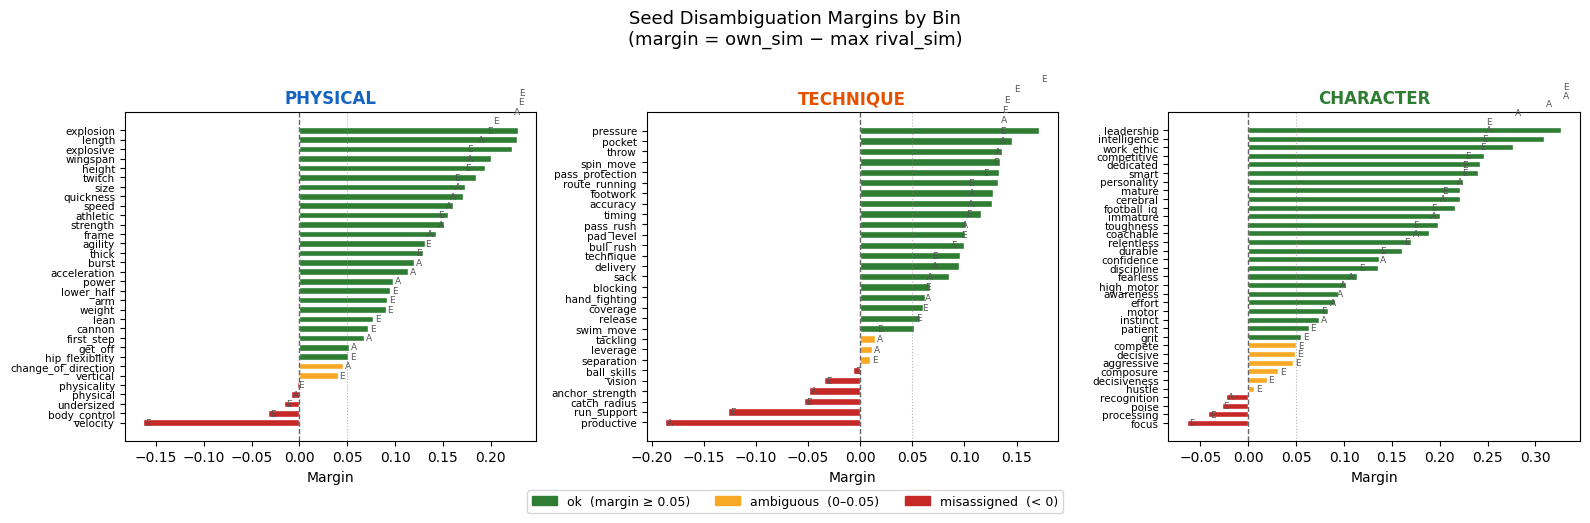

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BIN_COLOR = {'physical': '#1565C0', 'technique': '#E65100', 'character': '#2E7D32'}

df_plot = df_diag[df_diag['in_vocab'] == True].copy()
df_plot = df_plot.sort_values(['bin', 'margin'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Seed Disambiguation Margins by Bin\n(margin = own_sim − max rival_sim)', fontsize=13)

for ax, b in zip(axes, BIN_NAMES):
    sub = df_plot[df_plot['bin'] == b].reset_index(drop=True)
    colors = sub['verdict'].map({'ok': '#2E7D32', 'ambiguous': '#F9A825', 'misassigned': '#C62828'})
    bars = ax.barh(sub['seed'], sub['margin'], color=colors, edgecolor='white', height=0.7)
    ax.axvline(0,    color='black', linewidth=1.0, linestyle='--', alpha=0.6)
    ax.axvline(0.05, color='grey',  linewidth=0.8, linestyle=':',  alpha=0.6, label='threshold (0.05)')
    ax.set_title(b.upper(), color=BIN_COLOR[b], fontsize=12, fontweight='bold')
    ax.set_xlabel('Margin')
    ax.tick_params(axis='y', labelsize=7.5)
    # annotate source (anchor vs extra)
    for i, (_, row) in enumerate(sub.iterrows()):
        tag = 'A' if row['source'] == 'anchor' else 'E'
        ax.text(row['margin'] + 0.002, i, tag, va='center', fontsize=6.5, color='#555')

legend_patches = [
    mpatches.Patch(color='#2E7D32', label='ok  (margin ≥ 0.05)'),
    mpatches.Patch(color='#F9A825', label='ambiguous  (0–0.05)'),
    mpatches.Patch(color='#C62828', label='misassigned  (< 0)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()